In [4]:
import pandas as pd
import os
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, mean_squared_error, roc_curve, auc, confusion_matrix, precision_recall_curve, average_precision_score
from typing import List
import json
import os
import re

In [32]:
def load_scores_from_json(filepath):
    """Loads the observed estimator AND baseline scores from a single bootstrap JSON file."""
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    match = re.search(r'(rep_\d+)', data['config']['pred_csv'])
    model_name = match.group(1) if match else os.path.basename(filepath)

    # --- UPDATED: Get both estimator and baseline scores ---
    acc = data['observed_scores']['Accuracy']['estimator']
    acc_base = data['observed_scores']['Accuracy']['baseline']
    
    # Get F1 score (using the 'F1_score' key from your JSON)
    f1 = data['observed_scores']['F1_score']['estimator']
    f1_base = data['observed_scores']['F1_score']['baseline']
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1_score": f1,
        "Accuracy_baseline": acc_base,
        "F1_score_baseline": f1_base
    }

def plot_roc_panel(ax, true_labels_list, pred_probs_list):
    """Plots the K-Fold ROC curve on a given matplotlib axis."""
    n_splits = len(true_labels_list)
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    # Plot individual fold ROCs
    for i in range(n_splits):
        fpr, tpr, _ = roc_curve(true_labels_list[i], pred_probs_list[i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    # Plot chance line
    ax.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='#404040', label='Chance')

    # Plot Mean ROC and Std Dev
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    ax.plot(mean_fpr, mean_tpr, color='#0C5DA5',
            label=f'Mean ROC (AUC = {mean_auc:.2f} $\\pm$ {std_auc:.2f})',
            lw=2.0)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='#D9D9D9',
                    label=r'$\pm$ 1 std. dev.')

    # Formatting
    ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
           xlabel="False Positive Rate",
           ylabel="True Positive Rate")
    ax.set_title("A) ROC Curve Analysis", loc='left', fontweight='bold')
    ax.legend(loc="lower right", fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_pr_panel(ax, true_labels_list, pred_probs_list):
    """Plots the K-Fold Precision-Recall curve on a given matplotlib axis."""
    n_splits = len(true_labels_list)
    precisions = []
    auprcs = []
    mean_recall = np.linspace(0, 1, 100)
    
    # Calculate positive class fraction for no-skill line
    all_true_flat = np.concatenate(true_labels_list)
    no_skill = np.sum(all_true_flat) / len(all_true_flat)

    # Plot individual fold PR curves
    for i in range(n_splits):
        y_true = true_labels_list[i]
        y_prob = pred_probs_list[i]
        
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
        auprcs.append(auprc)
        
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
        precisions.append(interp_precision)
        
    # Plot no-skill line
    ax.plot([0, 1], [no_skill, no_skill], linestyle='--', lw=1.5, color='#404040', label=f'No Skill (AP={no_skill:.2f})')

    # Plot Mean PR and Std Dev
    mean_precision = np.mean(precisions, axis=0)
    mean_auprc = np.mean(auprcs)
    std_auprc = np.std(auprcs)
    
    ax.plot(mean_recall, mean_precision, color='#0C5DA5',
            label=f'Mean PR (AP = {mean_auprc:.2f} $\\pm$ {std_auprc:.2f})',
            lw=2.0)
            
    std_precision = np.std(precisions, axis=0)
    precisions_upper = np.minimum(mean_precision + std_precision, 1)
    precisions_lower = np.maximum(mean_precision - std_precision, 0)
    ax.fill_between(mean_recall, precisions_lower, precisions_upper, color='#D9D9D9',
                    label=r'$\pm$ 1 std. dev.')

    # Formatting
    ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
           xlabel="Recall (Sensitivity)",
           ylabel="Precision")
    ax.set_title("B) Precision-Recall Curve Analysis", loc='left', fontweight='bold')
    ax.legend(loc="lower left", fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_metrics_boxplot_panel(ax, metrics_dict):
    """Plots boxplots of key performance metrics on a given axis."""
    df = pd.DataFrame(metrics_dict)
    
    sns.boxplot(data=df, ax=ax, palette="Blues", width=0.5)
    
    if len(df) <= 10:
        sns.stripplot(data=df, ax=ax, color=".3", size=4)
        
    ax.set_ylabel("Score")
    ax.set_title("C) Cross-Validation Metrics", loc='left', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)


def plot_confusion_matrix_panel(ax, true_labels_list, pred_labels_list):
    """Calculates and plots an aggregated confusion matrix with counts and percentages."""
    total_cm = np.zeros((2, 2), dtype=int)
    
    for y_true, y_pred in zip(true_labels_list, pred_labels_list):
        total_cm += confusion_matrix(y_true, y_pred, labels=[0, 1])
        
    # --- Calculate row-wise percentages ---
    cm_percent = total_cm.astype('float') / total_cm.sum(axis=1)[:, np.newaxis]
    
    # --- Create labels combining counts and percentages ---
    annot_labels = (
        np.asarray([
            f"{count}\n({percent:.1%})"
            for count, percent in zip(total_cm.flatten(), cm_percent.flatten())
        ])
    ).reshape(total_cm.shape)

    sns.heatmap(total_cm, annot=annot_labels, fmt='s', cmap='Blues',
                xticklabels=['Predicted Neg', 'Predicted Pos'],
                yticklabels=['Actual Neg', 'Actual Pos'],
                ax=ax, cbar=False, annot_kws={"size": 12})
    
    ax.set_title("D) Aggregated Confusion Matrix", loc='left', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.yticks(rotation=0)

def plot_average_performance(ax, melted_df, n_models):
    """
    Plots a grouped bar chart of mean model performance vs. baseline
    on a given axis.
    
    Args:
        ax (matplotlib.axes.Axes): The axis to plot on.
        melted_df (pd.DataFrame): The melted DataFrame with 'Metric', 'Score', 
                                  and 'Score_Type' columns.
        n_models (int): The number of models (replicates) used for the title.
    """
    
    # --- Define colors ---
    palette = {
        "Estimator": "#4582c0", # Blue
        "Baseline": "#c4c4c4"   # Grey
    }

    # --- Plotting ---
    sns.barplot(
        data=melted_df,
        x='Metric',
        y='Score',
        hue='Score_Type',
        palette=palette,
        edgecolor='black',
        capsize=0.1,
        ax=ax  # Tell seaborn to use the provided axis
    )

    # --- Aesthetics ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_title("C) Average Model Performance", loc='left', fontweight='bold')
    ax.set_xlabel("Metric", fontsize=12)
    ax.set_ylabel("Mean Observed Score (± 95% CI)", fontsize=12)
    
    ax.set_ylim(0.5, 1.0) # Widen Y-axis to show baseline
    
    ax.legend(title='Score Type', loc='upper right')

In [33]:
selected_models = ["_rep_5", "_rep_6", "_rep_7", "_rep_9", "_rep_10"]
#selected_models = ["_fold_1", "_fold_2", "_fold_3", "_fold_4", "_fold_5"]
root_dir = "/scratch/alpine/fana6609/ML/PLM-Epistasis"
result_dir = "results"
data_dir = "data"
info_df = pd.read_csv(os.path.join(root_dir, data_dir, "input_info_VRC01_IC80.csv"))
task_type = "classification"

variants_of_interest = ["2769", "0790", "1714", "1586", "0514"]
virus_dict = {}
for variant in variants_of_interest:
    virus_dict[variant] = {}
    no = list(info_df.loc[info_df["Seq_name"].str.contains(variant), "Seq_no"])
    virus_dict[variant]["Seq_no"] = no

In [34]:
all_true_labels = []
all_pred_probs = []
all_pred_labels = []
for i, model_id in enumerate(selected_models):
    predict_df = pd.read_csv(os.path.join(root_dir, result_dir, "predictions",task_type,"train"+model_id+".csv"))
    true_labels = predict_df["Label"].values
    pred_labels = []
    pos_pred_probabilities = []
    neg_pred_probabilities = []

    for pred in predict_df["Prediction"]:
        pred_0 = float(pred.split()[1].split(",")[0])
        pred_1 = float(pred.split()[3].split("}")[0])
        
        pos_pred_probabilities.append(pred_1)
        neg_pred_probabilities.append(pred_0)
        
        if pred_0 > pred_1:
            pred_labels.append(0)
        else:
            pred_labels.append(1)

    pred_labels = np.array(pred_labels)
    assert len(true_labels) == len(pred_labels)

    print("Model:", "train" + model_id + ".csv")
    print("Accuracy:", accuracy_score(true_labels, pred_labels))
    print("AUC Score:", roc_auc_score(true_labels, pos_pred_probabilities))
    print("F1 Score:", f1_score(true_labels, pred_labels))
    
    all_true_labels.append(true_labels)
    all_pred_probs.append(pos_pred_probabilities)
    all_pred_labels.append(pred_labels)

Model: train_rep_5.csv
Accuracy: 0.9482564679415073
AUC Score: 0.9788758842587921
F1 Score: 0.9228187919463087
Model: train_rep_6.csv
Accuracy: 0.953880764904387
AUC Score: 0.9821158308949651
F1 Score: 0.9324546952224053
Model: train_rep_7.csv
Accuracy: 0.9493813273340832
AUC Score: 0.9853613829751454
F1 Score: 0.9256198347107438
Model: train_rep_9.csv
Accuracy: 0.9381327334083239
AUC Score: 0.978948755030886
F1 Score: 0.9081803005008348
Model: train_rep_10.csv
Accuracy: 0.9493813273340832
AUC Score: 0.9839768383053622
F1 Score: 0.9256198347107438


In [35]:
model_names = ["rep_5", "rep_6", "rep_7", "rep_9", "rep_10"]
json_directory = "results/bootstrap"

all_scores = []
for model in model_names:
    filename = f"bootstrap_{model}.json"
    filepath = os.path.join(root_dir, json_directory, filename)
    
    scores = load_scores_from_json(filepath)
    all_scores.append(scores)

# 1. Create the base DataFrame
df = pd.DataFrame(all_scores)

# 2. Rename columns for cleaner plotting labels
df = df.rename(columns={
    "F1_score": "F1 Score",
    "F1_score_baseline": "F1 Score_baseline"
})

# 3. "Melt" the DataFrame into a long format
melted_df = df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'F1 Score', 'Accuracy_baseline', 'F1 Score_baseline'],
    var_name='Metric_Type',
    value_name='Score'
)

# 4. Split Metric_Type into Metric and Score_Type
melted_df['Score_Type'] = melted_df['Metric_Type'].apply(
    lambda x: 'Baseline' if 'baseline' in x else 'Estimator'
)
melted_df['Metric'] = melted_df['Metric_Type'].str.replace('_baseline', '')

print("Loaded and fully melted Data:")
print(melted_df.head())

Loaded and fully melted Data:
    Model Metric_Type     Score Score_Type    Metric
0   rep_5    Accuracy  0.948256  Estimator  Accuracy
1   rep_6    Accuracy  0.953881  Estimator  Accuracy
2   rep_7    Accuracy  0.949381  Estimator  Accuracy
3   rep_9    Accuracy  0.938133  Estimator  Accuracy
4  rep_10    Accuracy  0.949381  Estimator  Accuracy


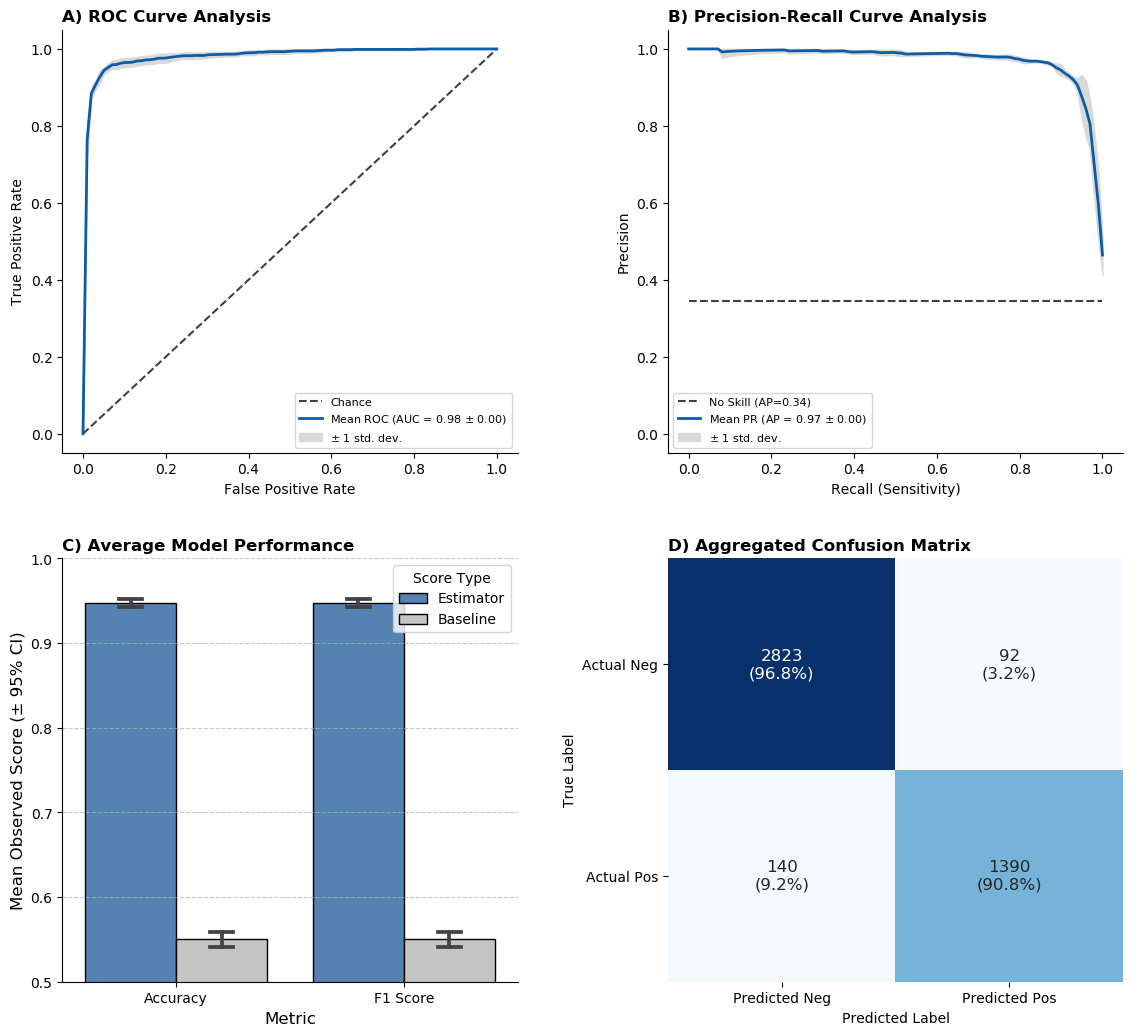


--- Summary Metrics (Mean +/- Std Dev) ---
AUC: 0.982 +/- 0.003
F1 Score: 0.923 +/- 0.008
Accuracy: 0.948 +/- 0.005


In [36]:
N_SPLITS = len(selected_models)
fold_metrics = {'AUC': [], 'F1 Score': [], 'Accuracy': []}
for i in range(N_SPLITS):
    fold_metrics['AUC'].append(auc(roc_curve(all_true_labels[i], all_pred_probs[i])[0], 
                                   roc_curve(all_true_labels[i], all_pred_probs[i])[1]))
    fold_metrics['F1 Score'].append(f1_score(all_true_labels[i], all_pred_labels[i], average='binary')) # Use 'binary' or 'weighted' as appropriate
    fold_metrics['Accuracy'].append(accuracy_score(all_true_labels[i], all_pred_labels[i]))


# --- Create the Multi-Panel Figure ---
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

# Panel A: ROC Curve
plot_roc_panel(axes[0, 0], all_true_labels, all_pred_probs)

# Panel B: Precision-Recall Curve
plot_pr_panel(axes[0, 1], all_true_labels, all_pred_probs)

# Panel C: Bar Plots of Metrics
#plot_metrics_boxplot_panel(axes[1, 0], fold_metrics)
n_models = melted_df['Model'].nunique()
plot_average_performance(axes[1, 0], melted_df, n_models)

# Panel D: Confusion Matrix
plot_confusion_matrix_panel(axes[1, 1], all_true_labels, all_pred_labels)

# Adjust layout and display
plt.tight_layout(pad=3.0) # Add padding between subplots
plt.show()

# --- Print Mean Metrics ---
print("\n--- Summary Metrics (Mean +/- Std Dev) ---")
for metric_name, values in fold_metrics.items():
    print(f"{metric_name}: {np.mean(values):.3f} +/- {np.std(values):.3f}")